# gammanet_contour_quadrant_final

Deze notebook analyseert afbeeldingen uit:

`/home/yentl/pytorch_gammanet/Images_quad_final`

Doel:
1. afbeeldingen inladen en forwarden door VGG16-$\gamma$Net;
2. in `h1_exc` het gemiddelde nemen over alle 128 kanalen;
3. per contourtype (`C`, `straight`) en per quadrant (`TL`, `TR`, `BL`, `BR`) een mean activation heatmap maken;
4. per afbeelding de activatiekaart in vier gelijke quadranten verdelen;
5. per quadrant de gemiddelde activatie berekenen;
6. bepalen of het quadrant met de hoogste activatie overeenkomt met het contour-quadrant uit de bestandsnaam (`yes`/`no`).


In [1]:
# ============================================================
# 1. Imports, paths and settings
# ============================================================
import os, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PROJECT_ROOT = Path("/home/yentl/pytorch_gammanet")
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoint_epoch_40.pt"

IMAGE_DIR = PROJECT_ROOT / "Images_quad_final_1"
OUTPUT_DIR = PROJECT_ROOT / "outputs_bias_contour_quadrant_final_1"
PLOT_DIR = OUTPUT_DIR / "plots"
CSV_DIR = OUTPUT_DIR / "csv"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

INPUT_SIZE = (320, 320)

ANALYSIS_LAYER = "h1_exc"
CONTOURS = ["C", "straight"]
QUADRANTS = ["TL", "TR", "BL", "BR"]

# Zoals in de eerdere notebooks: absolute activatie gebruiken voordat er over kanalen wordt gemiddeld.
USE_ABS_ACTIVATION = True

transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
])

print("IMAGE_DIR:", IMAGE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("ANALYSIS_LAYER:", ANALYSIS_LAYER)


Using device: cpu
IMAGE_DIR: /home/yentl/pytorch_gammanet/Images_quad_final_1
OUTPUT_DIR: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1
ANALYSIS_LAYER: h1_exc


In [2]:
# ============================================================
# 2. Model and helper functions
# ============================================================
def load_model():
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from gammanet.models.vgg16_gammanet_v2 import VGG16GammaNetV2

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    if "config" in checkpoint and "model" in checkpoint["config"]:
        model_config = checkpoint["config"]["model"]
    elif "model_config" in checkpoint:
        model_config = checkpoint["model_config"]
    else:
        raise KeyError("Could not find model config in checkpoint.")

    model = VGG16GammaNetV2(model_config)

    state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict", None))
    if state_dict is None:
        raise KeyError("Could not find model_state_dict or state_dict in checkpoint.")

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    model.to(DEVICE)
    model.eval()
    print("Model timesteps:", model.timesteps)
    return model


def normalize_contour_label(label):
    lower = str(label).strip().lower()
    if lower in ["c", "ccontour", "c_contour"]:
        return "C"
    if lower in ["straight", "line", "straightline", "straight_line"]:
        return "straight"
    return str(label)


def parse_image_filename(path):
    """
    Probeert bestandsnamen te lezen zoals in de eerdere notebooks.

    Ondersteunde voorbeelden:
    - C_BL_0_J000_000.png
    - C_high_BL_0_J000_000.png
    - straight_low_TR_0_J000_012.png

    Belangrijk voor deze analyse:
    - contour_type: C of straight
    - contour_quadrant: TL, TR, BL of BR
    """
    parts = path.stem.split("_")

    if len(parts) == 5:
        contour, quadrant, position, jitter, stim_id = parts
        contrast = "NA"
    elif len(parts) >= 6:
        contour, contrast, quadrant, position, jitter, stim_id = parts[:6]
    else:
        return None

    contour_type = normalize_contour_label(contour)
    quadrant = str(quadrant).upper()

    if contour_type not in CONTOURS:
        return None
    if quadrant not in QUADRANTS:
        return None

    try:
        jitter_int = int(str(jitter).replace("J", ""))
    except Exception:
        jitter_int = np.nan

    try:
        position_int = int(position)
    except Exception:
        position_int = np.nan

    try:
        stim_id_int = int(stim_id)
    except Exception:
        stim_id_int = np.nan

    return {
        "filename": path.name,
        "path": str(path),
        "contour_type": contour_type,
        "contrast": contrast,
        "contour_quadrant": quadrant,
        "position": position_int,
        "jitter": jitter_int,
        "stimulus_id": stim_id_int,
    }


def load_image_tensor(path):
    pil_img = Image.open(path).convert("RGB")
    img_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)
    return pil_img, img_tensor


def reset_and_forward(model, img_tensor):
    model.reset_hidden_states()
    with torch.no_grad():
        _ = model(img_tensor)


def get_state(model, layer_name):
    state = getattr(model, layer_name, None)
    if state is None:
        raise ValueError(f"{layer_name} is None. Run model first or check layer name.")
    return state


def mean_all_channel_map(state, use_abs=True):
    """Neem het gemiddelde over alle kanalen van een activatiemap: [1, C, H, W] -> [H, W]."""
    x = state.detach()
    if use_abs:
        x = x.abs()
    return x.mean(dim=1)[0].cpu().numpy()


def resize_map_to_image(fmap, pil_img):
    fmap_t = torch.tensor(fmap, dtype=torch.float32)[None, None]
    resized = F.interpolate(
        fmap_t,
        size=pil_img.size[::-1],
        mode="bilinear",
        align_corners=False
    )
    return resized[0, 0].numpy()


def normalize_for_plot(x, eps=1e-8):
    x = np.asarray(x)
    x = x - np.nanmin(x)
    return x / (np.nanmax(x) + eps)


def quadrant_slices(height, width):
    """Geeft vier exact even grote quadrants. Bij oneven maten wordt eerst het centrale randje genegeerd."""
    h2 = height // 2
    w2 = width // 2

    # Alle quadranten krijgen exact h2*w2 pixels.
    return {
        "TL": (slice(0, h2), slice(0, w2)),
        "TR": (slice(0, h2), slice(w2, 2*w2)),
        "BL": (slice(h2, 2*h2), slice(0, w2)),
        "BR": (slice(h2, 2*h2), slice(w2, 2*w2)),
    }


def quadrant_means(fmap):
    """Bereken gemiddelde activatie per quadrant."""
    h, w = fmap.shape
    slices = quadrant_slices(h, w)
    return {q: float(np.nanmean(fmap[ys, xs])) for q, (ys, xs) in slices.items()}


def highest_quadrant(q_means):
    """Geeft het quadrant met de hoogste gemiddelde activatie terug."""
    return max(q_means, key=q_means.get)


def plot_heatmap(fmap, title, save_path, pil_img=None):
    plt.figure(figsize=(5, 5))
    plt.imshow(normalize_for_plot(fmap), cmap="magma")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()


In [3]:
# ============================================================
# 3. Load model and image table
# ============================================================
model = load_model()

rows = []
for path in sorted(IMAGE_DIR.glob("*.png")):
    info = parse_image_filename(path)
    if info is not None:
        rows.append(info)

image_df = pd.DataFrame(rows)

if image_df.empty:
    raise RuntimeError(
        f"No valid C/straight images with TL/TR/BL/BR quadrant labels found in {IMAGE_DIR}. "
        "Check the filename pattern."
    )

image_df = image_df.sort_values(
    ["contour_type", "contour_quadrant", "filename"]
).reset_index(drop=True)

print("Number of images:", len(image_df))
print(image_df.groupby(["contour_type", "contour_quadrant"]).size())

display(image_df.head())


/tmp/ipykernel_2369/1732919091.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
/home/yentl/anaconda3/envs/

Missing keys: 0
Unexpected keys: 18
Model timesteps: 4
Number of images: 48
contour_type  contour_quadrant
C             BL                  6
              BR                  6
              TL                  6
              TR                  6
straight      BL                  6
              BR                  6
              TL                  6
              TR                  6
dtype: int64


,filename,path,contour_type,contrast,contour_quadrant,position,jitter,stimulus_id
0,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,0
1,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,1
2,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,2
3,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,3
4,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,4


In [4]:
# ============================================================
# 4. Forward all images and collect h1 mean activation maps
# ============================================================
# Per image:
# - state in h1_exc
# - average over all 128 channels
# - resize activation map to the original image size
# - compute mean activation in all four quadrants
# - compare highest-activation quadrant with the contour quadrant from filename

records = []
activation_maps = {}

for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Running model"):
    pil_img, img_tensor = load_image_tensor(row["path"])

    reset_and_forward(model, img_tensor)
    state = get_state(model, ANALYSIS_LAYER)

    fmap = mean_all_channel_map(state, use_abs=USE_ABS_ACTIVATION)
    fmap_resized = resize_map_to_image(fmap, pil_img)

    q_means = quadrant_means(fmap_resized)
    q_highest = highest_quadrant(q_means)
    match = "yes" if q_highest == row["contour_quadrant"] else "no"

    key = (row["filename"])
    activation_maps[key] = fmap_resized

    records.append({
        "filename": row["filename"],
        "path": row["path"],
        "contour_type": row["contour_type"],
        "contour_quadrant": row["contour_quadrant"],
        "contrast": row["contrast"],
        "position": row["position"],
        "jitter": row["jitter"],
        "stimulus_id": row["stimulus_id"],
        "mean_activation_TL": q_means["TL"],
        "mean_activation_TR": q_means["TR"],
        "mean_activation_BL": q_means["BL"],
        "mean_activation_BR": q_means["BR"],
        "highest_activation_quadrant": q_highest,
        "matches_contour_quadrant": match,
    })

quadrant_results_df = pd.DataFrame(records)
quadrant_results_df = quadrant_results_df.sort_values(
    ["contour_type", "contour_quadrant", "filename"]
).reset_index(drop=True)

csv_path = CSV_DIR / "h1_quadrant_activation_results.csv"
quadrant_results_df.to_csv(csv_path, index=False)

print("Saved:", csv_path)
display(quadrant_results_df.head())


Running model:   0%|          | 0/48 [00:00<?, ?it/s]

Running model: 100%|██████████| 48/48 [04:54<00:00,  6.14s/it]

Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/csv/h1_quadrant_activation_results.csv


,filename,path,contour_type,contour_quadrant,contrast,position,jitter,stimulus_id,mean_activation_TL,mean_activation_TR,mean_activation_BL,mean_activation_BR,highest_activation_quadrant,matches_contour_quadrant
0,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,0,2.192982,2.049956,2.439559,2.116556,BL,yes
1,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,1,2.126863,2.112510,2.463916,2.074187,BL,yes
2,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,2,2.123085,2.054855,2.545203,2.071339,BL,yes
3,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,3,2.142717,2.106175,2.483400,2.077167,BL,yes
4,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,4,2.162015,2.066000,2.439198,2.119545,BL,yes


In [5]:
# ============================================================
# 5. Summary tables: yes/no performance per contour and quadrant
# ============================================================
summary_df = (
    quadrant_results_df
    .groupby(["contour_type", "contour_quadrant"])
    .agg(
        n_images=("filename", "count"),
        n_match=("matches_contour_quadrant", lambda x: (x == "yes").sum()),
        proportion_match=("matches_contour_quadrant", lambda x: (x == "yes").mean()),
        mean_TL=("mean_activation_TL", "mean"),
        mean_TR=("mean_activation_TR", "mean"),
        mean_BL=("mean_activation_BL", "mean"),
        mean_BR=("mean_activation_BR", "mean"),
    )
    .reset_index()
)

summary_path = CSV_DIR / "h1_quadrant_activation_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(summary_df)


Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/csv/h1_quadrant_activation_summary.csv


,contour_type,contour_quadrant,n_images,n_match,proportion_match,mean_TL,mean_TR,mean_BL,mean_BR
0,C,BL,6,6,1.000000,2.140709,2.084872,2.471346,2.097260
1,C,BR,6,5,0.833333,2.194186,2.046022,2.247348,2.293069
2,C,TL,6,6,1.000000,2.403957,2.058936,2.218129,2.107588
3,C,TR,6,0,0.000000,2.187205,2.186728,2.289779,2.115523
4,straight,BL,6,6,1.000000,2.223386,2.119456,2.319842,2.128466
5,straight,BR,6,1,0.166667,2.200548,2.075364,2.296773,2.219327
6,straight,TL,6,4,0.666667,2.304111,2.066350,2.288682,2.134221
7,straight,TR,6,0,0.000000,2.208744,2.185573,2.297318,2.114507


In [6]:
# ============================================================
# 6. Mean activation heatmaps per contour x quadrant
# ============================================================
# Dit maakt 2 contourtypes x 4 quadranten = 8 heatmaps.
# Elke heatmap is het gemiddelde van de h1 all-channel mean activation maps
# voor die specifieke contour/quadrant-combinatie.

MEAN_HEATMAP_DIR = PLOT_DIR / "mean_h1_heatmaps_by_contour_quadrant"
MEAN_HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

mean_maps = {}

for contour in CONTOURS:
    for quadrant in QUADRANTS:
        subset = quadrant_results_df[
            (quadrant_results_df["contour_type"] == contour) &
            (quadrant_results_df["contour_quadrant"] == quadrant)
        ]

        if subset.empty:
            print(f"Skipping {contour} {quadrant}: no images")
            continue

        maps = [activation_maps[fn] for fn in subset["filename"]]
        mean_map = np.mean(np.stack(maps, axis=0), axis=0)
        mean_maps[(contour, quadrant)] = mean_map

        save_path = MEAN_HEATMAP_DIR / f"mean_h1_all_channels_{contour}_{quadrant}.png"
        title = f"{contour} contour in {quadrant} | h1 mean over all channels"
        plot_heatmap(mean_map, title, save_path)
        print("Saved:", save_path)


Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_by_contour_quadrant/mean_h1_all_channels_C_TL.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_by_contour_quadrant/mean_h1_all_channels_C_TR.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_by_contour_quadrant/mean_h1_all_channels_C_BL.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_by_contour_quadrant/mean_h1_all_channels_C_BR.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_by_contour_quadrant/mean_h1_all_channels_straight_TL.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_by_contour_quadrant/mean_h1_all_channels_straight_TR.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_by_cont

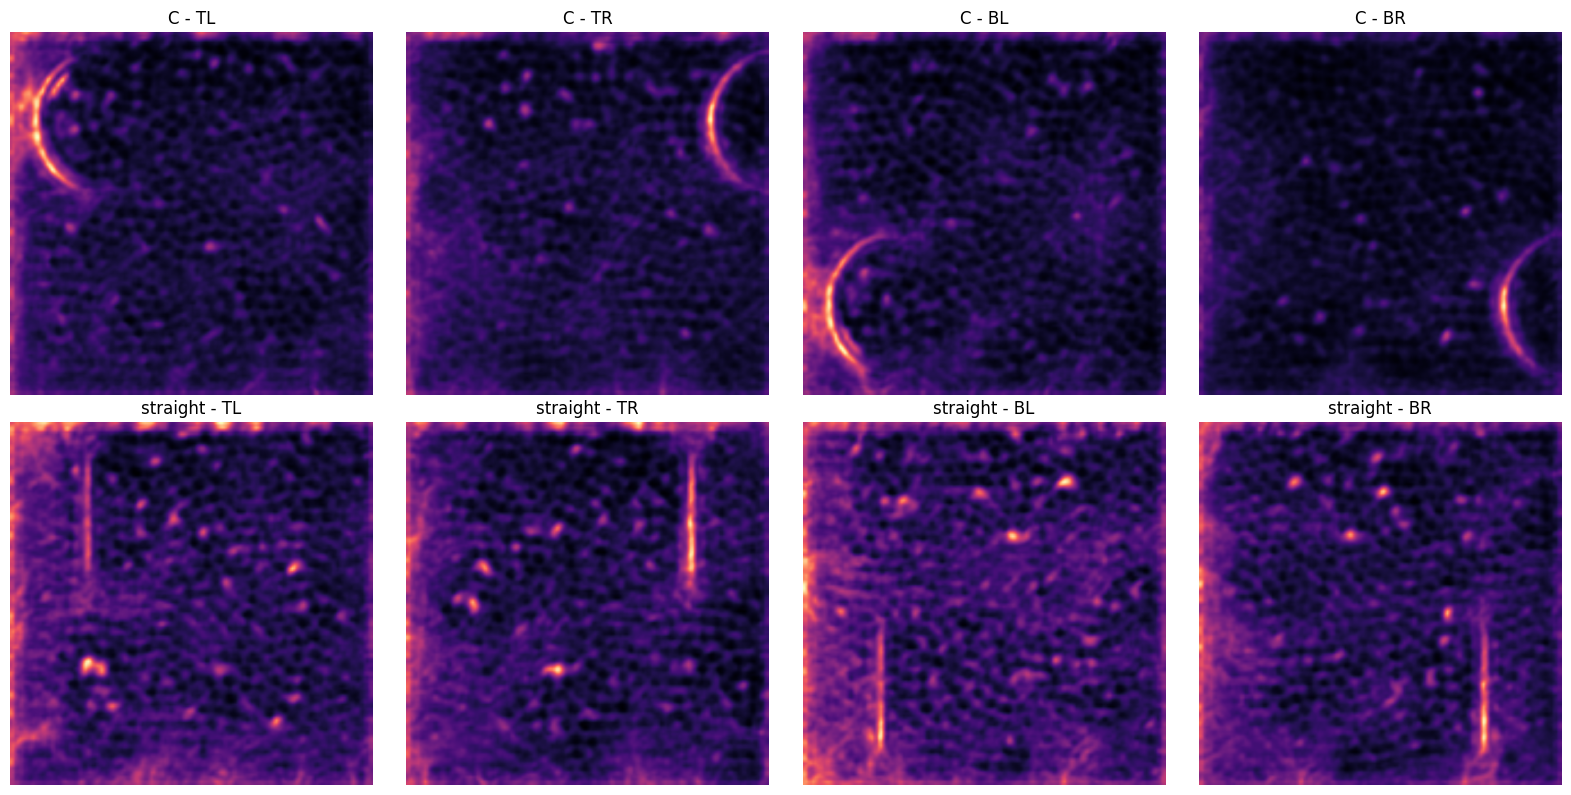

Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/plots/mean_h1_heatmaps_8_conditions.png


In [7]:
# ============================================================
# 7. Combined figure with all 8 heatmaps
# ============================================================
combined_path = PLOT_DIR / "mean_h1_heatmaps_8_conditions.png"

fig, axes = plt.subplots(
    nrows=len(CONTOURS),
    ncols=len(QUADRANTS),
    figsize=(4 * len(QUADRANTS), 4 * len(CONTOURS))
)

for i, contour in enumerate(CONTOURS):
    for j, quadrant in enumerate(QUADRANTS):
        ax = axes[i, j]
        key = (contour, quadrant)
        if key in mean_maps:
            ax.imshow(normalize_for_plot(mean_maps[key]), cmap="magma")
            ax.set_title(f"{contour} - {quadrant}")
        else:
            ax.set_title(f"{contour} - {quadrant}\nNo data")
        ax.axis("off")

plt.tight_layout()
plt.savefig(combined_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", combined_path)


In [8]:
# ============================================================
# 8. Optional visual check: show quadrant means for a few images
# ============================================================
# Handig om snel te controleren of de output logisch is.

cols_to_show = [
    "filename",
    "contour_type",
    "contour_quadrant",
    "mean_activation_TL",
    "mean_activation_TR",
    "mean_activation_BL",
    "mean_activation_BR",
    "highest_activation_quadrant",
    "matches_contour_quadrant",
]

display(quadrant_results_df[cols_to_show].head(20))


,filename,contour_type,contour_quadrant,mean_activation_TL,mean_activation_TR,mean_activation_BL,mean_activation_BR,highest_activation_quadrant,matches_contour_quadrant
0,C_BL_0_J000_000.png,C,BL,2.192982,2.049956,2.439559,2.116556,BL,yes
1,C_BL_0_J000_001.png,C,BL,2.126863,2.112510,2.463916,2.074187,BL,yes
2,C_BL_0_J000_002.png,C,BL,2.123085,2.054855,2.545203,2.071339,BL,yes
3,C_BL_0_J000_003.png,C,BL,2.142717,2.106175,2.483400,2.077167,BL,yes
4,C_BL_0_J000_004.png,C,BL,2.162015,2.066000,2.439198,2.119545,BL,yes
5,C_BL_0_J000_005.png,C,BL,2.096590,2.119735,2.456799,2.124765,BL,yes
6,C_BR_0_J000_000.png,C,BR,2.226350,2.035460,2.239172,2.280134,BR,yes
7,C_BR_0_J000_001.png,C,BR,2.235233,2.022397,2.224156,2.277763,BR,yes
8,C_BR_0_J000_002.png,C,BR,2.166091,2.068558,2.281584,2.279654,BL,no
9,C_BR_0_J000_003.png,C,BR,2.167471,2.053806,2.269756,2.287914,BR,yes


## Output

Na het runnen van de notebook staan de belangrijkste bestanden hier:

- `outputs_contour_quadrant_final/csv/h1_quadrant_activation_results.csv`  
  Per afbeelding de gemiddelde activatie per quadrant, het quadrant met hoogste activatie en `yes`/`no`.

- `outputs_contour_quadrant_final/csv/h1_quadrant_activation_summary.csv`  
  Samenvatting per contourtype en contour-quadrant.

- `outputs_contour_quadrant_final/plots/mean_h1_heatmaps_by_contour_quadrant/`  
  Acht losse mean activation heatmaps.

- `outputs_contour_quadrant_final/plots/mean_h1_heatmaps_8_conditions.png`  
  Eén overzichtsfiguur met alle acht heatmaps.


## 9. Matched top-down bias: quadrant-analyse opnieuw uitvoeren

De onderstaande cellen gebruiken dezelfde C/straight-kanaalverdeling en dezelfde bias-grootte als in `gammanet_bias_jitter_contour_final.ipynb`. Daarna wordt dezelfde quadrant-analyse opnieuw uitgevoerd, maar nu met matched bias: C-afbeeldingen krijgen C-channel bias en straight-afbeeldingen krijgen straight-channel bias.


In [9]:
# ============================================================
# 9. Load C/straight channels and bias settings
# ============================================================
# Deze cel gebruikt dezelfde kanaalverdeling en bias strength als het
# gammanet_bias_jitter_contour_final notebook.

CLASSIFICATION_DIR = (
    PROJECT_ROOT
    / "outputs_bias_contour_final"
    / "plots"
    / "05_channel_classification"
    / "channel_classification"
)

C_CHANNELS_CSV = CLASSIFICATION_DIR / "C_channels_h1.csv"
STRAIGHT_CHANNELS_CSV = CLASSIFICATION_DIR / "straight_channels_h1.csv"

BIAS_STRENGTH = 0.25

def load_channel_list(csv_path):
    """
    Laadt een lijst met channel indices.
    Verwacht normaal een kolom 'channel', maar heeft een fallback
    voor het geval de csv anders is opgeslagen.
    """
    df = pd.read_csv(csv_path)

    if "channel" in df.columns:
        channels = df["channel"].astype(int).tolist()
    else:
        # Fallback: neem de eerste numerieke kolom
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) == 0:
            raise ValueError(f"No numeric channel column found in {csv_path}")
        channels = df[numeric_cols[0]].astype(int).tolist()

    return channels


if not C_CHANNELS_CSV.exists() or not STRAIGHT_CHANNELS_CSV.exists():
    raise FileNotFoundError(
        "Channel classification files not found.\n"
        f"Expected C channels here: {C_CHANNELS_CSV}\n"
        f"Expected straight channels here: {STRAIGHT_CHANNELS_CSV}\n\n"
        "Run gammanet_bias_contour_final.ipynb first, or check CLASSIFICATION_DIR."
    )

C_CHANNELS = load_channel_list(C_CHANNELS_CSV)
STRAIGHT_CHANNELS = load_channel_list(STRAIGHT_CHANNELS_CSV)

print(f"Loaded {len(C_CHANNELS)} C channels from: {C_CHANNELS_CSV}")
print(f"Loaded {len(STRAIGHT_CHANNELS)} straight channels from: {STRAIGHT_CHANNELS_CSV}")
print("Bias strength:", BIAS_STRENGTH)


Loaded 61 C channels from: /home/yentl/pytorch_gammanet/outputs_bias_contour_final/plots/05_channel_classification/channel_classification/C_channels_h1.csv
Loaded 67 straight channels from: /home/yentl/pytorch_gammanet/outputs_bias_contour_final/plots/05_channel_classification/channel_classification/straight_channels_h1.csv
Bias strength: 0.25


In [10]:
# ============================================================
# 10. Top-down bias hook and matched-bias forward pass
# ============================================================
# Dit is dezelfde bias-logica als in gammanet_bias_jitter_contour_final:
# er wordt een niet-invasieve bias toegevoegd na td_fgru_1, dus op td_h1.

class TDH1Bias:
    """
    Adds a non-invasive top-down bias after td_fgru_1,
    i.e. to the td_h1 channels.
    """
    def __init__(self, model, channels, strength=0.25, mode="add_mean_abs"):
        self.model = model
        self.channels = [int(c) for c in channels]
        self.strength = float(strength)
        self.mode = mode
        self.handle = None

    def _hook(self, module, inputs, output):
        if not isinstance(output, tuple):
            return output

        exc = output[0]

        if exc is None or len(self.channels) == 0:
            return output

        exc = exc.clone()
        idx = torch.tensor(self.channels, device=exc.device, dtype=torch.long)

        if self.mode == "add_mean_abs":
            scale = exc.detach().abs().mean(dim=(2, 3), keepdim=True) + 1e-8
            exc[:, idx, :, :] = exc[:, idx, :, :] + self.strength * scale[:, idx, :, :]

        elif self.mode == "multiply":
            exc[:, idx, :, :] = exc[:, idx, :, :] * (1.0 + self.strength)

        else:
            raise ValueError(f"Unknown bias mode: {self.mode}")

        return (exc,) + output[1:]

    def __enter__(self):
        self.handle = self.model.td_fgru_1.register_forward_hook(self._hook)
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        if self.handle is not None:
            self.handle.remove()
        return False


def forward_condition(model, img_tensor, condition, C_CHANNELS, STRAIGHT_CHANNELS):
    if condition == "baseline":
        return reset_and_forward(model, img_tensor)

    if condition == "C_bias":
        with TDH1Bias(model, C_CHANNELS, strength=BIAS_STRENGTH):
            return reset_and_forward(model, img_tensor)

    if condition == "straight_bias":
        with TDH1Bias(model, STRAIGHT_CHANNELS, strength=BIAS_STRENGTH):
            return reset_and_forward(model, img_tensor)

    raise ValueError(f"Unknown condition: {condition}")


def matched_condition_for_contour(contour_type):
    contour_type = normalize_contour_label(contour_type)

    if contour_type == "C":
        return "C_bias"

    if contour_type == "straight":
        return "straight_bias"

    raise ValueError(f"Unknown contour type: {contour_type}")


# Snelle check
print("Matched condition for C:", matched_condition_for_contour("C"))
print("Matched condition for straight:", matched_condition_for_contour("straight"))


Matched condition for C: C_bias
Matched condition for straight: straight_bias


In [11]:
# ============================================================
# 11. Re-run quadrant analysis with matched top-down bias
# ============================================================
# Per afbeelding:
# - als contour_type == C: C-channel bias
# - als contour_type == straight: straight-channel bias
# - daarna h1_exc pakken
# - gemiddelde nemen over alle 128 h1-kanalen
# - gemiddelde activatie per quadrant berekenen
# - hoogste-activatie-quadrant vergelijken met contour_quadrant uit bestandsnaam

BIAS_OUTPUT_DIR = OUTPUT_DIR / "matched_bias_025_quadrant_analysis"
BIAS_PLOT_DIR = BIAS_OUTPUT_DIR / "plots"
BIAS_CSV_DIR = BIAS_OUTPUT_DIR / "csv"

BIAS_PLOT_DIR.mkdir(parents=True, exist_ok=True)
BIAS_CSV_DIR.mkdir(parents=True, exist_ok=True)

bias_records = []
bias_activation_maps = {}

for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Running matched bias quadrant analysis"):
    pil_img, img_tensor = load_image_tensor(row["path"])

    condition = matched_condition_for_contour(row["contour_type"])

    forward_condition(
        model=model,
        img_tensor=img_tensor,
        condition=condition,
        C_CHANNELS=C_CHANNELS,
        STRAIGHT_CHANNELS=STRAIGHT_CHANNELS,
    )

    state = get_state(model, ANALYSIS_LAYER)

    # Net als baseline: gemiddelde over alle 128 h1-kanalen,
    # maar nu nadat de matched top-down bias is toegepast.
    fmap = mean_all_channel_map(state, use_abs=USE_ABS_ACTIVATION)
    fmap_resized = resize_map_to_image(fmap, pil_img)

    q_means = quadrant_means(fmap_resized)
    q_highest = highest_quadrant(q_means)
    match = "yes" if q_highest == row["contour_quadrant"] else "no"

    bias_activation_maps[row["filename"]] = fmap_resized

    bias_records.append({
        "filename": row["filename"],
        "path": row["path"],
        "contour_type": row["contour_type"],
        "contour_quadrant": row["contour_quadrant"],
        "contrast": row["contrast"],
        "position": row["position"],
        "jitter": row["jitter"],
        "stimulus_id": row["stimulus_id"],
        "condition": condition,
        "bias_strength": BIAS_STRENGTH,
        "mean_activation_TL": q_means["TL"],
        "mean_activation_TR": q_means["TR"],
        "mean_activation_BL": q_means["BL"],
        "mean_activation_BR": q_means["BR"],
        "highest_activation_quadrant": q_highest,
        "matches_contour_quadrant": match,
    })

bias_quadrant_results_df = pd.DataFrame(bias_records)
bias_quadrant_results_df = bias_quadrant_results_df.sort_values(
    ["contour_type", "contour_quadrant", "filename"]
).reset_index(drop=True)

bias_results_path = BIAS_CSV_DIR / "h1_quadrant_activation_results_matched_bias_025.csv"
bias_quadrant_results_df.to_csv(bias_results_path, index=False)

print("Saved:", bias_results_path)
display(bias_quadrant_results_df.head())


Running matched bias quadrant analysis: 100%|██████████| 48/48 [05:04<00:00,  6.34s/it]

Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/csv/h1_quadrant_activation_results_matched_bias_025.csv


,filename,path,contour_type,contour_quadrant,contrast,position,jitter,stimulus_id,condition,bias_strength,mean_activation_TL,mean_activation_TR,mean_activation_BL,mean_activation_BR,highest_activation_quadrant,matches_contour_quadrant
0,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,0,C_bias,0.25,2.568185,2.413814,2.836821,2.481243,BL,yes
1,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,1,C_bias,0.25,2.482742,2.468009,2.879032,2.443048,BL,yes
2,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,2,C_bias,0.25,2.492941,2.410066,2.961653,2.435570,BL,yes
3,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,3,C_bias,0.25,2.516069,2.470574,2.867877,2.455136,BL,yes
4,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,0,0,4,C_bias,0.25,2.525332,2.427410,2.850425,2.486130,BL,yes


In [12]:
# ============================================================
# 12. Summary and baseline-vs-bias comparison
# ============================================================

bias_summary_df = (
    bias_quadrant_results_df
    .groupby(["contour_type", "contour_quadrant", "condition", "bias_strength"])
    .agg(
        n_images=("filename", "count"),
        n_match=("matches_contour_quadrant", lambda x: (x == "yes").sum()),
        proportion_match=("matches_contour_quadrant", lambda x: (x == "yes").mean()),
        mean_TL=("mean_activation_TL", "mean"),
        mean_TR=("mean_activation_TR", "mean"),
        mean_BL=("mean_activation_BL", "mean"),
        mean_BR=("mean_activation_BR", "mean"),
    )
    .reset_index()
)

bias_summary_path = BIAS_CSV_DIR / "h1_quadrant_activation_summary_matched_bias_025.csv"
bias_summary_df.to_csv(bias_summary_path, index=False)

print("Saved:", bias_summary_path)
display(bias_summary_df)


# Baseline en matched bias in één tabel zetten
baseline_compare_df = quadrant_results_df.copy()
baseline_compare_df["condition"] = "baseline"
baseline_compare_df["bias_strength"] = 0.0

bias_compare_df = bias_quadrant_results_df.copy()

compare_df = pd.concat(
    [baseline_compare_df, bias_compare_df],
    ignore_index=True,
    sort=False,
)

compare_summary_df = (
    compare_df
    .groupby(["condition", "bias_strength", "contour_type", "contour_quadrant"])
    .agg(
        n_images=("filename", "count"),
        n_match=("matches_contour_quadrant", lambda x: (x == "yes").sum()),
        proportion_match=("matches_contour_quadrant", lambda x: (x == "yes").mean()),
    )
    .reset_index()
)

compare_summary_path = BIAS_CSV_DIR / "baseline_vs_matched_bias_quadrant_match_summary.csv"
compare_summary_df.to_csv(compare_summary_path, index=False)

print("Saved:", compare_summary_path)
display(compare_summary_df)


Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/csv/h1_quadrant_activation_summary_matched_bias_025.csv


,contour_type,contour_quadrant,condition,bias_strength,n_images,n_match,proportion_match,mean_TL,mean_TR,mean_BL,mean_BR
0,C,BL,C_bias,0.25,6,6,1.000000,2.508576,2.446834,2.873764,2.466868
1,C,BR,C_bias,0.25,6,5,0.833333,2.571689,2.400607,2.623136,2.682494
2,C,TL,C_bias,0.25,6,6,1.000000,2.792382,2.418548,2.601369,2.475722
3,C,TR,C_bias,0.25,6,0,0.000000,2.558015,2.562698,2.676620,2.481703
4,straight,BL,straight_bias,0.25,6,6,1.000000,2.631930,2.508204,2.736200,2.521608
5,straight,BR,straight_bias,0.25,6,1,0.166667,2.605971,2.460641,2.715450,2.616044
6,straight,TL,straight_bias,0.25,6,4,0.666667,2.719427,2.454250,2.702147,2.528635
7,straight,TR,straight_bias,0.25,6,0,0.000000,2.612749,2.585488,2.711011,2.508799


Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/csv/baseline_vs_matched_bias_quadrant_match_summary.csv


,condition,bias_strength,contour_type,contour_quadrant,n_images,n_match,proportion_match
0,C_bias,0.25,C,BL,6,6,1.000000
1,C_bias,0.25,C,BR,6,5,0.833333
2,C_bias,0.25,C,TL,6,6,1.000000
3,C_bias,0.25,C,TR,6,0,0.000000
4,baseline,0.00,C,BL,6,6,1.000000
5,baseline,0.00,C,BR,6,5,0.833333
6,baseline,0.00,C,TL,6,6,1.000000
7,baseline,0.00,C,TR,6,0,0.000000
8,baseline,0.00,straight,BL,6,6,1.000000
9,baseline,0.00,straight,BR,6,1,0.166667


In [13]:
# ============================================================
# 13. Mean activation heatmaps with matched bias
# ============================================================
# Dit maakt opnieuw 2 contourtypes x 4 quadranten = 8 heatmaps,
# maar nu voor matched top-down bias.

BIAS_MEAN_HEATMAP_DIR = BIAS_PLOT_DIR / "mean_h1_heatmaps_by_contour_quadrant_matched_bias_025"
BIAS_MEAN_HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

bias_mean_maps = {}

for contour in CONTOURS:
    for quadrant in QUADRANTS:
        subset = bias_quadrant_results_df[
            (bias_quadrant_results_df["contour_type"] == contour) &
            (bias_quadrant_results_df["contour_quadrant"] == quadrant)
        ]

        if subset.empty:
            print(f"Skipping {contour} {quadrant}: no images")
            continue

        maps = [bias_activation_maps[fn] for fn in subset["filename"]]
        mean_map = np.mean(np.stack(maps, axis=0), axis=0)
        bias_mean_maps[(contour, quadrant)] = mean_map

        save_path = BIAS_MEAN_HEATMAP_DIR / f"mean_h1_all_channels_matched_bias_025_{contour}_{quadrant}.png"
        title = f"{contour} contour in {quadrant} | h1 mean | matched bias {BIAS_STRENGTH}"

        plot_heatmap(mean_map, title, save_path)
        print("Saved:", save_path)


Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/plots/mean_h1_heatmaps_by_contour_quadrant_matched_bias_025/mean_h1_all_channels_matched_bias_025_C_TL.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/plots/mean_h1_heatmaps_by_contour_quadrant_matched_bias_025/mean_h1_all_channels_matched_bias_025_C_TR.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/plots/mean_h1_heatmaps_by_contour_quadrant_matched_bias_025/mean_h1_all_channels_matched_bias_025_C_BL.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/plots/mean_h1_heatmaps_by_contour_quadrant_matched_bias_025/mean_h1_all_channels_matched_bias_025_C_BR.png
Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/plots/mean_h1_heatmaps_by_c

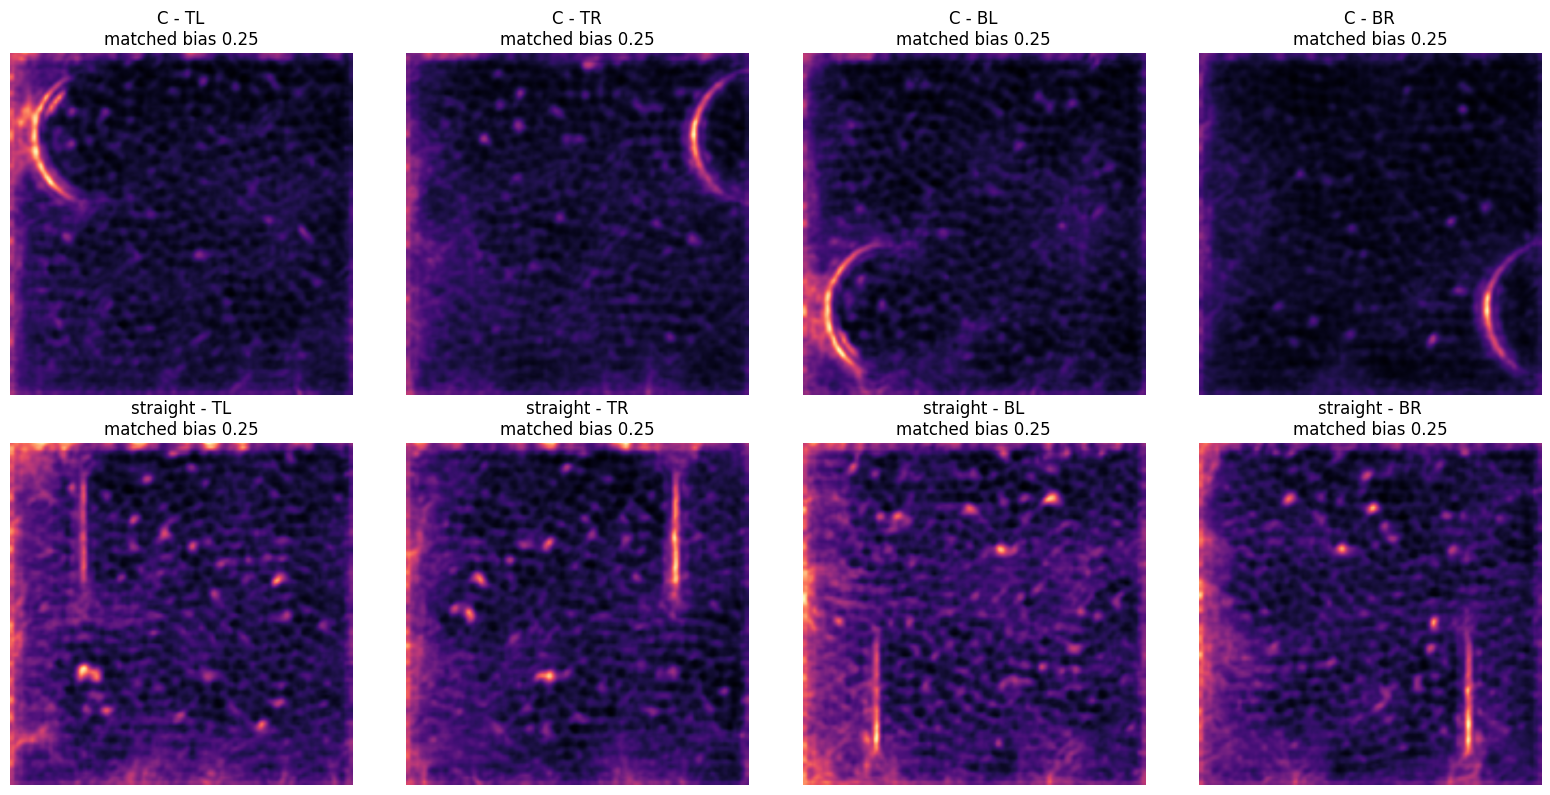

Saved: /home/yentl/pytorch_gammanet/outputs_bias_contour_quadrant_final_1/matched_bias_025_quadrant_analysis/plots/mean_h1_heatmaps_8_conditions_matched_bias_025.png


In [14]:
# ============================================================
# 14. Combined figure with all 8 matched-bias heatmaps
# ============================================================

combined_bias_path = BIAS_PLOT_DIR / "mean_h1_heatmaps_8_conditions_matched_bias_025.png"

fig, axes = plt.subplots(
    nrows=len(CONTOURS),
    ncols=len(QUADRANTS),
    figsize=(4 * len(QUADRANTS), 4 * len(CONTOURS))
)

for i, contour in enumerate(CONTOURS):
    for j, quadrant in enumerate(QUADRANTS):
        ax = axes[i, j]
        key = (contour, quadrant)

        if key in bias_mean_maps:
            ax.imshow(normalize_for_plot(bias_mean_maps[key]), cmap="magma")
            ax.set_title(f"{contour} - {quadrant}\nmatched bias {BIAS_STRENGTH}")
        else:
            ax.set_title(f"{contour} - {quadrant}\nNo data")

        ax.axis("off")

plt.tight_layout()
plt.savefig(combined_bias_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", combined_bias_path)


## Extra output na matched bias

Na het runnen van de nieuwe cellen staan de matched-bias outputs hier:

- `outputs_contour_quadrant_final/matched_bias_025_quadrant_analysis/csv/h1_quadrant_activation_results_matched_bias_025.csv`
- `outputs_contour_quadrant_final/matched_bias_025_quadrant_analysis/csv/h1_quadrant_activation_summary_matched_bias_025.csv`
- `outputs_contour_quadrant_final/matched_bias_025_quadrant_analysis/csv/baseline_vs_matched_bias_quadrant_match_summary.csv`
- `outputs_contour_quadrant_final/matched_bias_025_quadrant_analysis/plots/`
